In [4]:
## Importa as bibliotecas necessarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings("ignore")

## estilo visual consiste em todos os gráficos gerados atráves do estilo e tamanho definido
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

print("Imports OK")

Imports OK


In [10]:
## carrega o CSV do Kaggle
df = pd.read_csv(r"C:\Users\yagos\Downloads\churn-prediction\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"Shape: {df.shape}")
print(f"\nColunas:\n{df.dtypes}")
print(f"\nPrimeiras linhas:")
df.head()

Shape: (7043, 21)

Colunas:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Primeiras linhas:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


=== Distribuição de Churn ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Taxa de churn: 26.5%


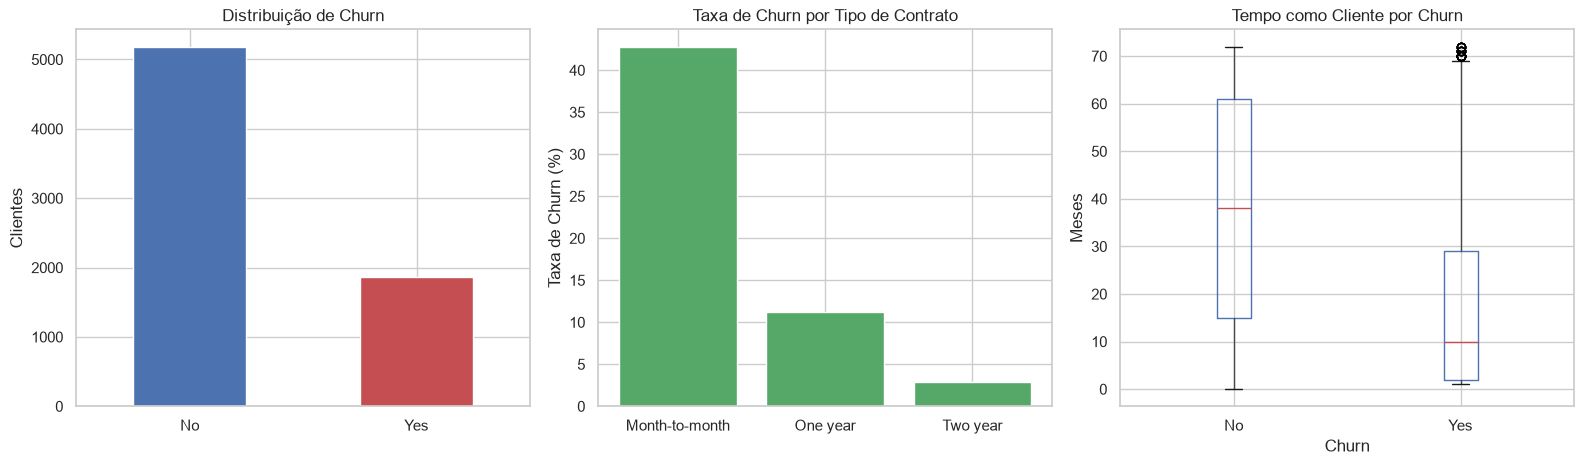

In [11]:
## distribuição do churn — confirma o desbalanceamento

print("=== Distribuição de Churn ===")
print(df["Churn"].value_counts())
print(f"\nTaxa de churn: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")

## visualização
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

## gráfico 1: distribuição de churn
df["Churn"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"])
axes[0].set_title("Distribuição de Churn")
axes[0].set_xlabel("")
axes[0].set_ylabel("Clientes")
axes[0].tick_params(axis="x", rotation=0)

## gráfico 2: churn por tipo de contrato
## hipótese: contratos mensais têm mais churn — clientes sem compromisso saem mais fácil
contract_churn = df.groupby("Contract")["Churn"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).reset_index()
contract_churn.columns = ["Contract", "ChurnRate"]
axes[1].bar(contract_churn["Contract"], contract_churn["ChurnRate"], color="#55A868")
axes[1].set_title("Taxa de Churn por Tipo de Contrato")
axes[1].set_ylabel("Taxa de Churn (%)")

## gráfico 3: distribuição de tenure (tempo como cliente) por churn
## hipótese: clientes novos saem mais — os que ficam tendem a ficar para sempre
df.boxplot(column="tenure", by="Churn", ax=axes[2],
           boxprops=dict(color="#4C72B0"),
           medianprops=dict(color="#C44E52"))
axes[2].set_title("Tempo como Cliente por Churn")
axes[2].set_xlabel("Churn")
axes[2].set_ylabel("Meses")
plt.suptitle("")

plt.tight_layout()
plt.savefig("../output/eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
## cria copia para não modificar o original

df_model = df.copy()
## TotalCharges veio como string (bug no dataset) — converte para Num
## erros='coerce' transforma valores não numéricos em NaN

df_model["TotalCharges"] = pd.to_numeric(df_model["TotalCharges"], errors="coerce")

## os NaN em TotalCharges são clientes com tenure=0 — preenche com 0
df_model["TotalCharges"] = df_model["TotalCharges"].fillna(0)

## remove customerID — identificador único sem poder preditivo
df_model = df_model.drop(columns=["customerID"])

## converte a variável alvo para binária: Yes=1, No=0
df_model["Churn"] = (df_model["Churn"] == "Yes").astype(int)

## identifica colunas categóricas e numéricas
cat_cols = df_model.select_dtypes(include="object").columns.tolist()
num_cols = df_model.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols.remove("Churn")  ## remove o target da lista de features

print(f"Colunas categóricas ({len(cat_cols)}): {cat_cols}")
print(f"Colunas numéricas ({len(num_cols)}): {num_cols}")

## Label Encoding para colunas binárias (Yes/No, Male/Female)
## One-Hot Encoding para colunas com mais de 2 categorias
binary_cols  = [c for c in cat_cols if df_model[c].nunique() == 2]
multi_cols   = [c for c in cat_cols if df_model[c].nunique() > 2]

le = LabelEncoder()
for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col])

## get_dummies faz one-hot encoding e já remove uma categoria para evitar multicolinearidade
df_model = pd.get_dummies(df_model, columns=multi_cols, drop_first=True)

print(f"\nShape após encoding: {df_model.shape}")
print(f"Features: {df_model.shape[1] - 1}")

Colunas categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Colunas numéricas (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Shape após encoding: (7043, 31)
Features: 30


In [13]:
## separa features e target
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

## 80% treino, 20% teste
## stratify=y garante que a proporção de churn seja igual nos dois splits
## random_state fixa a aleatoriedade — resultados reproduzíveis em situacao real
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## normaliza as features numéricas
## importante para Logistic Regression — sensível à escala
## Random Forest não precisa, mas normalizar ajuda
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   ## fit apenas no treino — evita data leakage
X_test  = scaler.transform(X_test)        ## transforma o teste com os parâmetros do treino

## treina os dois modelos
## class_weight='balanced' compensa o desbalanceamento do dataset
## sem isso, o modelo ignora a classe minoritária (churn=1)
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

## avaliação
for name, model in [("Logistic Regression", lr), ("Random Forest", rf)]:
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  AUC-ROC: {auc:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Ficou', 'Cancelou'])}")


  Logistic Regression
  AUC-ROC: 0.8414

              precision    recall  f1-score   support

       Ficou       0.90      0.72      0.80      1035
    Cancelou       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


  Random Forest
  AUC-ROC: 0.8225

              precision    recall  f1-score   support

       Ficou       0.87      0.81      0.84      1035
    Cancelou       0.56      0.66      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.78      1409



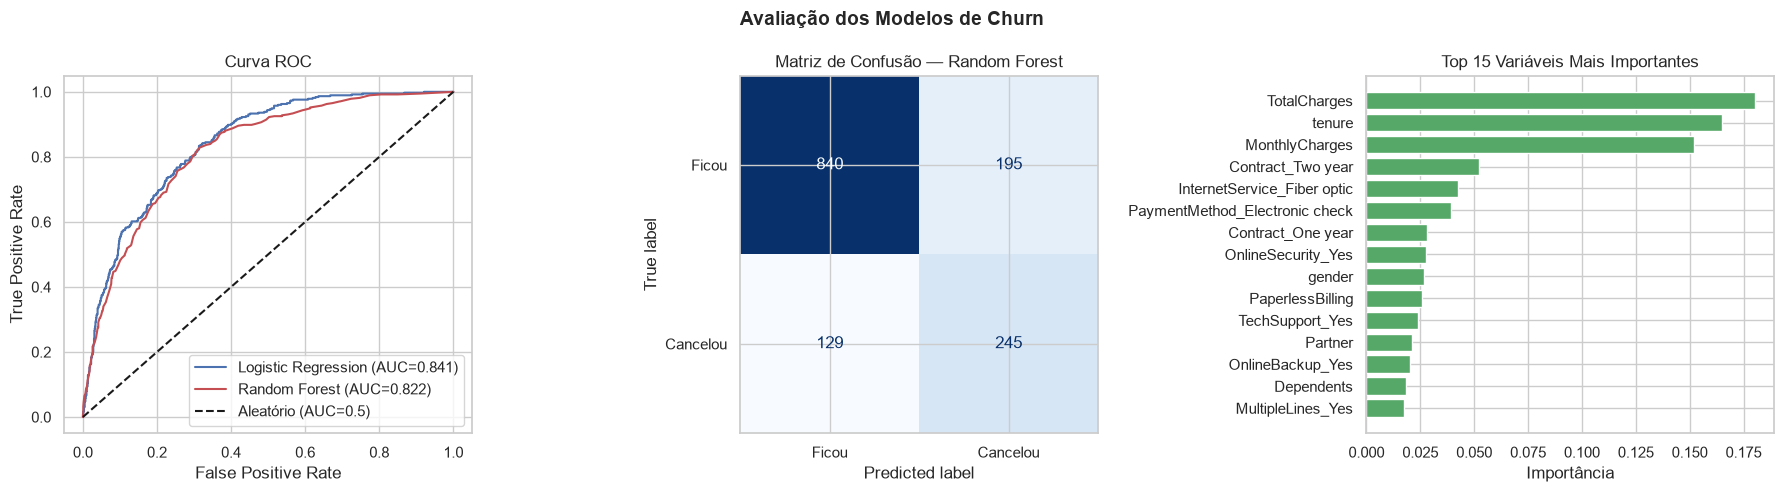

In [14]:
## cria titulo gráfico
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Avaliação dos Modelos de Churn", fontsize=14, fontweight="bold")

## gráfico 1: curva ROC dos dois modelos
## AUC = área sob a curva — quanto maior, melhor pra gente
## 0.5 = chute aleatório, 1.0 = modelo perfeito
for name, model, color in [
    ("Logistic Regression", lr, "#4C72B0"),
    ("Random Forest",       rf, "#C44E52")
]:
    y_proba  = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc      = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color)

axes[0].plot([0, 1], [0, 1], "k--", label="Aleatório (AUC=0.5)")
axes[0].set_title("Curva ROC")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

## gráfico 2: matriz de confusão do Random Forest
## mostra onde o modelo erra — falsos negativos são mais custosos
rf_pred = rf.predict(X_test)
ConfusionMatrixDisplay(
    confusion_matrix(y_test, rf_pred),
    display_labels=["Ficou", "Cancelou"]
).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Matriz de Confusão — Random Forest")

## gráfico 3: feature importance do Random Forest
## as 15 variáveis que mais influenciam a previsão de churn
feature_names = df_model.drop(columns=["Churn"]).columns
importances   = pd.Series(rf.feature_importances_, index=feature_names)
top15         = importances.nlargest(15).sort_values()

axes[2].barh(top15.index, top15.values, color="#55A868")
axes[2].set_title("Top 15 Variáveis Mais Importantes")
axes[2].set_xlabel("Importância")

plt.tight_layout()
plt.savefig("../output/churn_report.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
## resultados finais em linguagem de negócio
y_proba_rf = rf.predict_proba(X_test)[:, 1]
auc_lr     = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
auc_rf     = roc_auc_score(y_test, y_proba_rf)

top3 = importances.nlargest(3).index.tolist()

print("=" * 55)
print("  SUMÁRIO — MODELO DE PREVISÃO DE CHURN")
print("=" * 55)
print(f"  Clientes analisados      : {len(df):,}")
print(f"  Taxa de churn real       : {y.mean():.1%}")
print(f"  AUC Logistic Regression  : {auc_lr:.4f}")
print(f"  AUC Random Forest        : {auc_rf:.4f}")
print(f"  Modelo recomendado       : Random Forest")
print("=" * 55)
print(f"\n  TOP 3 FATORES DE CHURN:")
for i, feat in enumerate(top3, 1):
    print(f"  {i}. {feat}")
print()
print("  RECOMENDAÇÕES:")
print("  1. Priorizar retenção de clientes com contrato mensal")
print("  2. Acionar equipe de sucesso para clientes nos primeiros 12 meses")
print("  3. Revisar estratégia de precificação para fibra óptica")
print("=" * 55)

  SUMÁRIO — MODELO DE PREVISÃO DE CHURN
  Clientes analisados      : 7,043
  Taxa de churn real       : 26.5%
  AUC Logistic Regression  : 0.8414
  AUC Random Forest        : 0.8225
  Modelo recomendado       : Random Forest

  TOP 3 FATORES DE CHURN:
  1. TotalCharges
  2. tenure
  3. MonthlyCharges

  RECOMENDAÇÕES:
  1. Priorizar retenção de clientes com contrato mensal
  2. Acionar equipe de sucesso para clientes nos primeiros 12 meses
  3. Revisar estratégia de precificação para fibra óptica
